In [1]:
import tensorflow as tf
from tensorflow.keras import models,Sequential,layers
import matplotlib.pyplot as plt

In [2]:
BATCH_SIZE=32
EPOCHS=50
IMAGE_SIZE=256
CHANNELS=3

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    labels='inferred',
    label_mode='int',
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

(32, 256, 256, 3)
[1 2 1 1 2 0 0 1 1 1 1 0 0 1 1 0 0 2 0 0 1 0 0 0 1 0 0 1 0 2 2 0]
(32, 256, 256, 3)
[0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 2 0 0 0 1 1 2 2 0 1]
(32, 256, 256, 3)
[0 0 1 0 0 1 0 1 1 1 1 0 1 2 0 2 1 1 1 1 1 1 1 1 1 1 0 0 1 0 2 0]


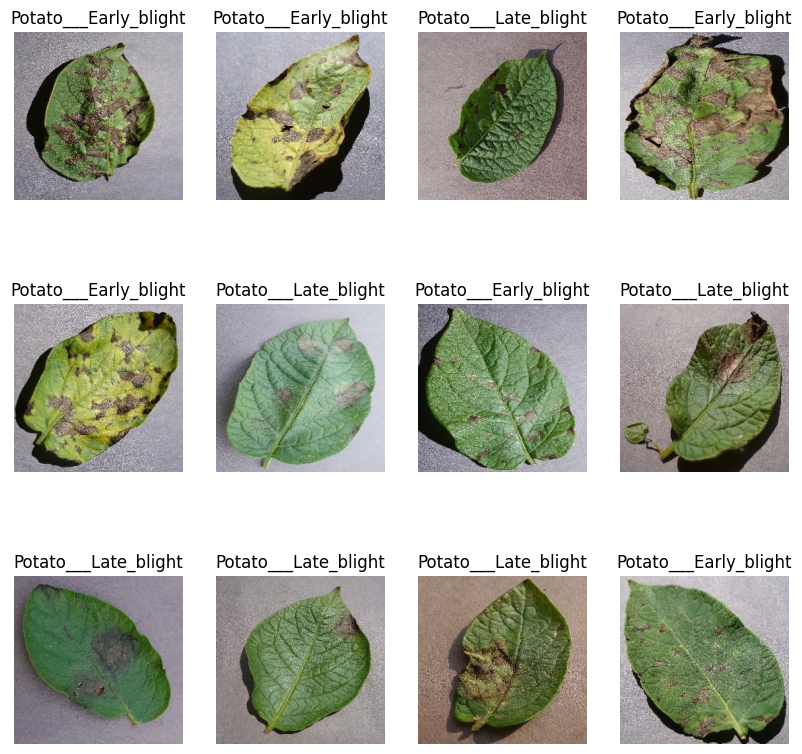

In [5]:
plt.figure(figsize=(10,10))
for image_batch,labels_batch in dataset.take(3):
    print(image_batch.shape)
    print(labels_batch.numpy())
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [6]:
def get_dataset_partition(ds,train_split=0.8,test_split=0.1,val_split=0.1,shuffle=True,shuffle_size=10000):
    assert(train_split+test_split+val_split)==1
    sz=len(ds)
    if shuffle==True:
        ds=ds.shuffle(shuffle_size,seed=12)

    train_size=int(train_split*sz)
    test_size=int(test_split*sz)
    val_size=int(val_split*sz)
    
    train_ds=ds.take(train_size)
    test_val_ds=ds.skip(train_size)
    test_ds=ds.take(test_size)
    val_ds=ds.take(val_size)
    
    return train_ds,test_ds,val_ds

In [7]:
train_ds,test_ds,val_ds=get_dataset_partition(dataset)

In [8]:
len(train_ds)

54

In [9]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [10]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])


In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [12]:
input_shape=(IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
model = Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Flatten(),
    
    layers.Dense(64,activation='relu'),
    
    layers.Dense(3,activation='softmax')
])

In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        'accuracy'
    ]
)

In [15]:
history=model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=1,
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5584 - loss: 0.8820 - val_accuracy: 0.7708 - val_loss: 0.7586
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7251 - loss: 0.6704 - val_accuracy: 0.7812 - val_loss: 0.4462
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8235 - loss: 0.4230 - val_accuracy: 0.8906 - val_loss: 0.3466
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8397 - loss: 0.4065 - val_accuracy: 0.8594 - val_loss: 0.3812
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8247 - loss: 0.4325 - val_accuracy: 0.8958 - val_loss: 0.2601
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8791 - loss: 0.3153 - val_accuracy: 0.8958 - val_loss: 0.2774
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8848 - loss: 0.2995 - val_accuracy: 0.8906 - val_loss: 0.2333
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9005 - loss: 0.2486 - val_accuracy: 0.9010 - val_loss:

In [18]:
scores=model.evaluate(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.9219 - loss: 0.1750


In [19]:
scores

[0.17495326697826385, 0.921875]

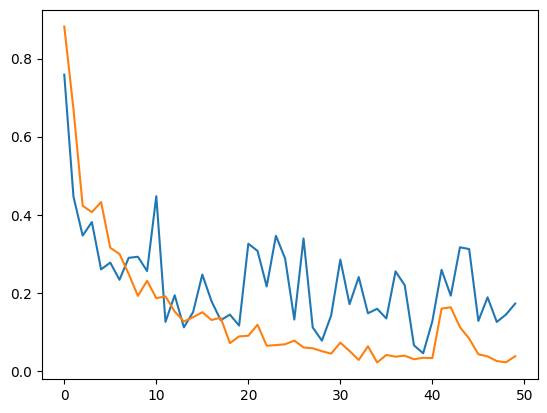

In [24]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['loss'])

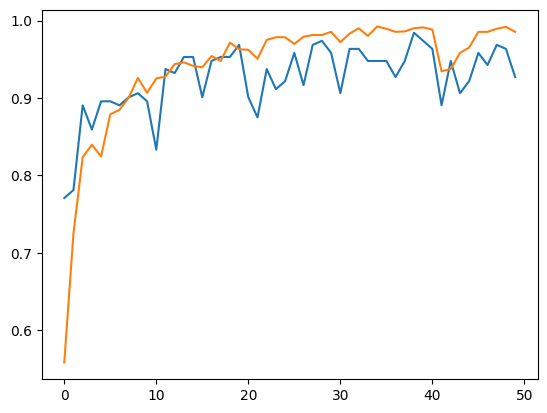

In [25]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])

True Label:  Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
Predicted Potato___Early_blight


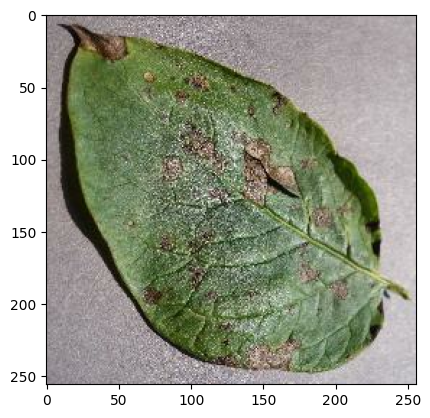

In [44]:
import numpy as np
for image_batch,labels_batch in test_ds.take(1):
    img=image_batch[0].numpy().astype("uint8")
    plt.imshow(img)
    print("True Label: ",class_names[labels_batch[0].numpy()])
    print("Predicted",class_names[np.argmax(model.predict(image_batch)[0])])

In [51]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)
    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*np.max(predictions[0]),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


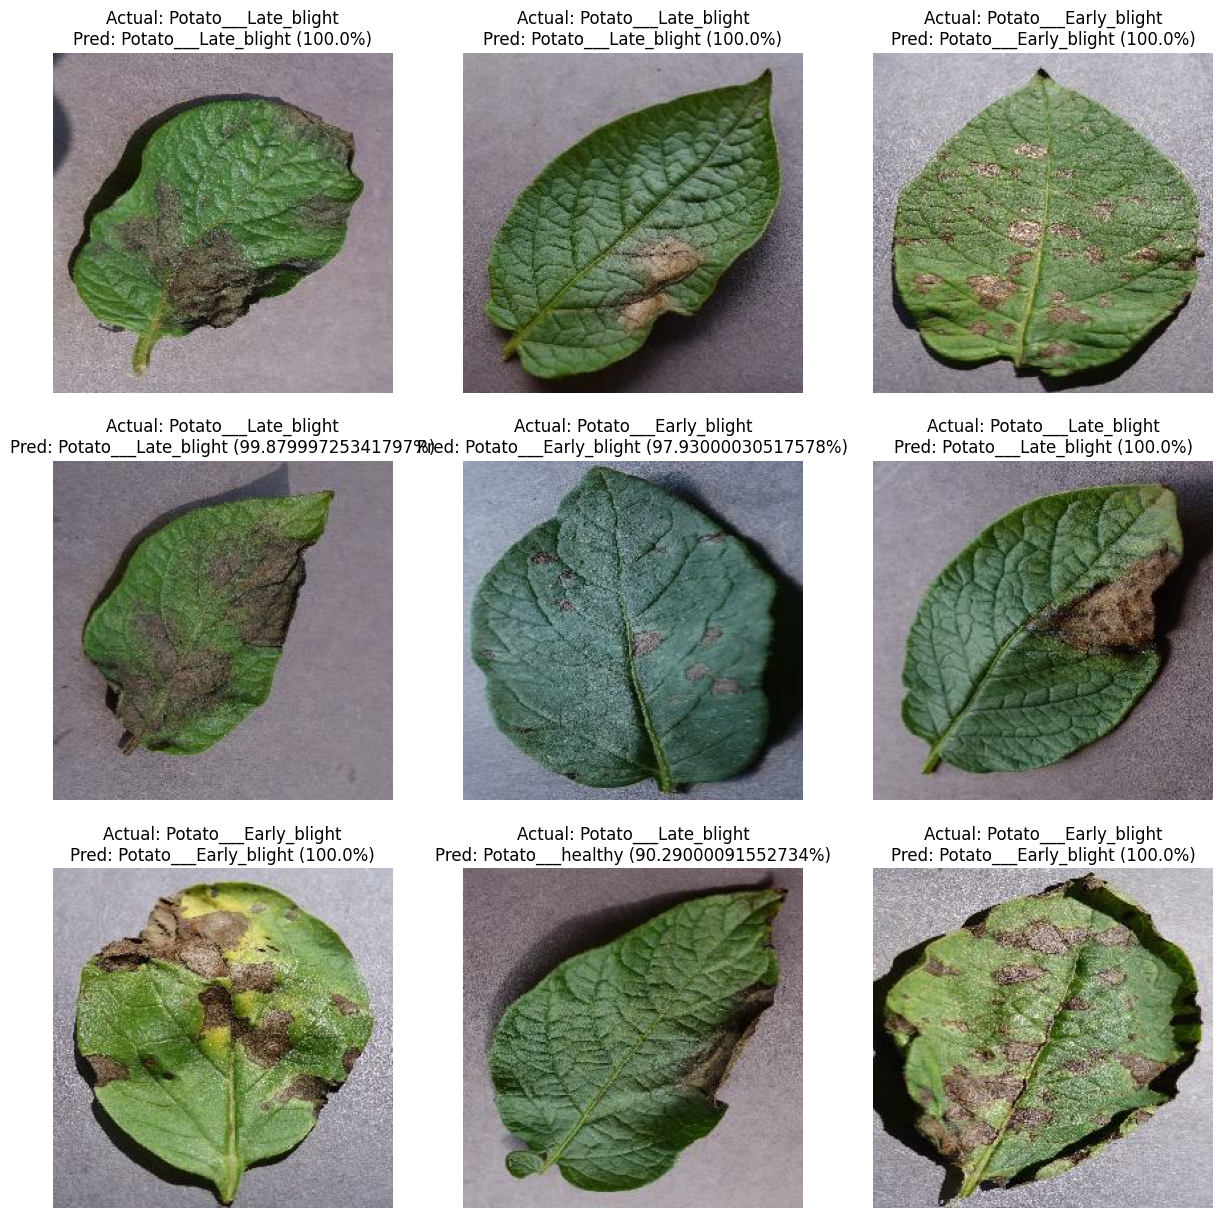

In [52]:
plt.figure(figsize=(15,15))

for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        
        img = images[i].numpy().astype("uint8")
        plt.imshow(img)
        
        predicted_class, confidence = predict(model, images[i])
        
        actual_class = class_names[labels[i]]
        
        plt.title(f"Actual: {actual_class}\nPred: {predicted_class} ({confidence}%)")
        plt.axis("off")

plt.show()

In [63]:
import os
model_version=max([int(i) for i in (os.listdir("../models")+[0])])+1

In [64]:
model.export(f"../models/{model_version}")

INFO:tensorflow:Assets written to: ../models/2\assets


INFO:tensorflow:Assets written to: ../models/2\assets


Saved artifact at '../models/2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2674161539920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674161535504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674161537232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674079753104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674079951632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674079093136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674079506192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674079093328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674079506384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674161542032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2674161543184: TensorSpec(shape=(), dty